<a href="https://colab.research.google.com/github/dindaaldiankhaira/digital_library/blob/main/Praktikum_Bab4_Clickbait.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Tugas praktikum bab 4.pdf to Tugas praktikum bab 4.pdf


In [3]:
!wget https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/emot_emotion-twitter/all_agree.csv

--2026-05-15 14:55:34--  https://raw.githubusercontent.com/indobenchmark/indonlu/master/dataset/emot_emotion-twitter/all_agree.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-15 14:55:34 ERROR 404: Not Found.



In [5]:
data = {
    'title': [
        'Wow kamu tidak akan percaya ini',
        'Cara belajar python dengan mudah',
        'Nomor 7 bikin kaget',
        'Tutorial machine learning lengkap',
        'Rahasia sukses orang kaya',
        'Belajar data science untuk pemula'
    ],
    'label_score': [1,0,1,0,1,0]
}

df = pd.DataFrame(data)

In [6]:
df.head()

,title,label_score
0,Wow kamu tidak akan percaya ini,1
1,Cara belajar python dengan mudah,0
2,Nomor 7 bikin kaget,1
3,Tutorial machine learning lengkap,0
4,Rahasia sukses orang kaya,1


In [7]:
df = df.dropna()
df['title'] = df['title'].str.lower()

In [8]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['title'])

y = df['label_score']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [11]:
y_pred = model.predict(X_test)

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.5


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


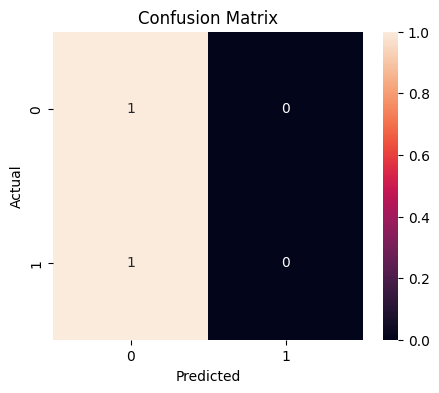

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()